1: Импорт библиотек (Code)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube

# Настройка устройства (GPU, если доступно, иначе CPU или MPS для Mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

# Зафиксируем сиды для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Используемое устройство: cpu


In [2]:
# --- Физические параметры ---
# --- Физические параметры ---
alpha = 0.05 # Коэффициент температуропроводности
T_max = 1.0 # Конечное время симуляции
L = 1.0 # Размер пластины (1x1)
# Температурные условия
# Количество точек
N_ic = 2000 # Точки для начального условия (t = 0)
N_bc = 4000 # Точки для граничных условий (края пластины)
N_col = 15000 # Точки коллокации внутри домена (для физики)

# Конвертируем всё в тензоры PyTorch и переносим на устройство (GPU/CPU)
def to_tensor(arr, requires_grad=False):
 tensor = torch.tensor(arr, dtype=torch.float32).to(device)
 tensor.requires_grad = requires_grad
 return tensor
# Температурные условия
T_0 = 20.0      # Начальная температура всей пластины и холодных краев
# Вместо фиксированного T_hot на границе, все края теперь холодные
T_ambient = 20.0 
    
# --- 1. Генерация точек коллокации (Physics) ---
sampler = LatinHypercube(d=3)
sample_points = sampler.random(n=N_col)

x_col = sample_points[:, 0:1] * L
y_col = sample_points[:, 1:2] * L
t_col = sample_points[:, 2:3] * T_max

x_col_t = to_tensor(x_col, requires_grad=True)
y_col_t = to_tensor(y_col, requires_grad=True)
t_col_t = to_tensor(t_col, requires_grad=True)

# --- 2. Начальные условия (IC) ---
x_ic = np.random.uniform(0, L, (N_ic, 1))
y_ic = np.random.uniform(0, L, (N_ic, 1))
t_ic = np.zeros((N_ic, 1))
u_ic = np.full((N_ic, 1), T_0)

x_ic_t, y_ic_t, t_ic_t, u_ic_t = to_tensor(x_ic), to_tensor(y_ic), to_tensor(t_ic), to_tensor(u_ic)

# --- 3. Граничные условия (BC) - все стороны холодные ---
N_edge = N_bc // 4
t_bc_all = np.random.uniform(0, T_max, (N_bc, 1))
pts = np.random.uniform(0, L, (N_bc, 1))

x_bc = np.zeros((N_bc, 1))
y_bc = np.zeros((N_bc, 1))
u_bc = np.full((N_bc, 1), T_0) 

# Заполнение сторон
# Bottom (y=0)
x_bc[0:N_edge] = pts[0:N_edge]; y_bc[0:N_edge] = 0.0
# Top (y=L)
x_bc[N_edge:2*N_edge] = pts[N_edge:2*N_edge]; y_bc[N_edge:2*N_edge] = L
# Left (x=0)
x_bc[2*N_edge:3*N_edge] = 0.0; y_bc[2*N_edge:3*N_edge] = pts[2*N_edge:3*N_edge]
# Right (x=L)
x_bc[3*N_edge:] = L; y_bc[3*N_edge:] = pts[3*N_edge:]

x_bc_t = to_tensor(x_bc)
y_bc_t = to_tensor(y_bc)
t_bc_t = to_tensor(t_bc_all)
u_bc_t = to_tensor(u_bc)

print(f"Данные созданы. BC точки: {len(x_bc)} (по {N_edge} на каждую из 4-х сторон)")

Данные созданы. BC точки: 4000 (по 1000 на каждую из 4-х сторон)


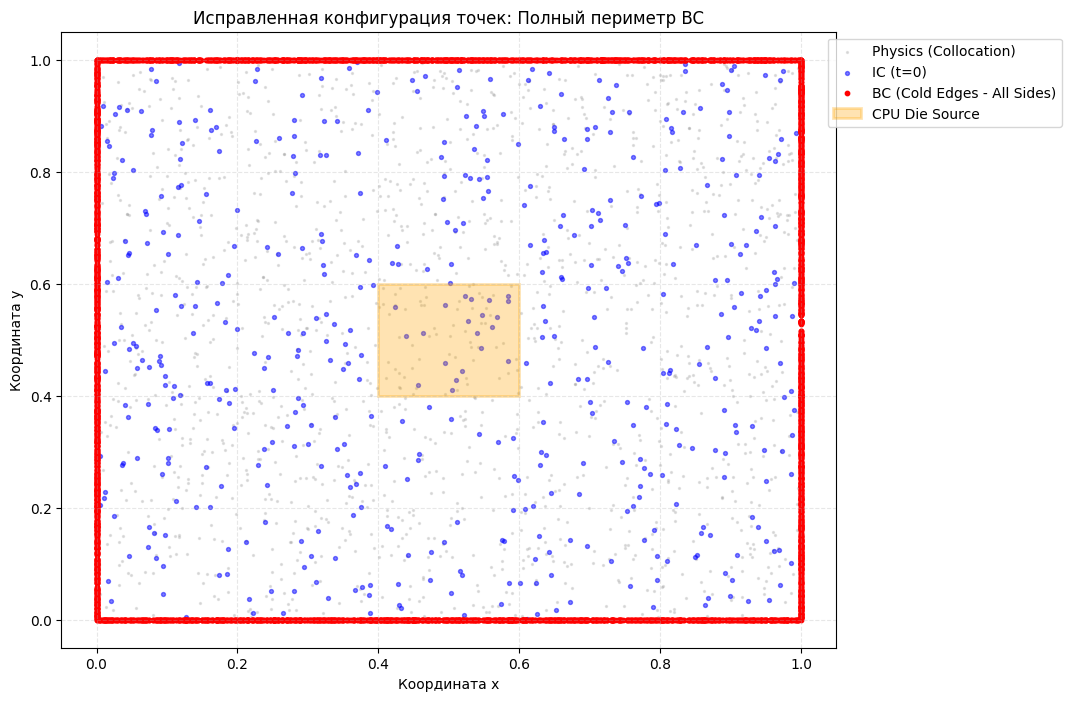

In [3]:
import matplotlib.patches as patches

plt.figure(figsize=(10, 8))

# Точки внутри (Physics)
plt.scatter(x_col[:1500], y_col[:1500], c='gray', s=2, alpha=0.2, label='Physics (Collocation)')

# Начальное состояние (t=0)
plt.scatter(x_ic[:500], y_ic[:500], c='blue', s=8, alpha=0.5, label='IC (t=0)')

# ГРАНИЦЫ (BC) - теперь рисуем все точки
plt.scatter(x_bc, y_bc, c='red', s=10, label='BC (Cold Edges - All Sides)')

# Область процессора
ax = plt.gca()
chip_rect = patches.Rectangle((0.4, 0.4), 0.2, 0.2, linewidth=2, 
                              edgecolor='orange', facecolor='orange', 
                              alpha=0.3, label='CPU Die Source')
ax.add_patch(chip_rect)

plt.title("Исправленная конфигурация точек: Полный периметр BC")
plt.xlabel("Координата x")
plt.ylabel("Координата y")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [4]:
class PINN(nn.Module):
    def __init__(self, num_hidden_layers=5, num_neurons=60):
        super(PINN, self).__init__()
        
        layers =[]
        # Входной слой: (x, y, t) -> 3 нейрона
        layers.append(nn.Linear(3, num_neurons))
        layers.append(nn.Tanh())
        
        # Скрытые слои
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.Tanh())
            
        # Выходной слой: 1 нейрон (температура u)
        layers.append(nn.Linear(num_neurons, 1))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x, y, t):
        # Объединяем тензоры в один вектор [N, 3]
        inputs = torch.cat([x, y, t], dim=1)
        return self.net(inputs)

model = PINN().to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=60, bias=True)
    (1): Tanh()
    (2): Linear(in_features=60, out_features=60, bias=True)
    (3): Tanh()
    (4): Linear(in_features=60, out_features=60, bias=True)
    (5): Tanh()
    (6): Linear(in_features=60, out_features=60, bias=True)
    (7): Tanh()
    (8): Linear(in_features=60, out_features=60, bias=True)
    (9): Tanh()
    (10): Linear(in_features=60, out_features=60, bias=True)
    (11): Tanh()
    (12): Linear(in_features=60, out_features=1, bias=True)
  )
)


In [6]:
# Загрузка весов модели, если файл существует
import os
is_trained = False
model_file = r'C:\Users\nasty\local_projects\PZAD\model\weight\checkpoint.pth'
if os.path.exists(model_file):
    try:
        model.load_state_dict(torch.load(model_file))
        print(f"✓ Веса модели загружены из '{model_file}'")
        is_trained = True
    except Exception as e:
        print(f"✗ Не удалось загрузить веса: {e}. Модель будет обучена с нуля.")
else:
    print(f"Файл с весами не найден ({model_file}), модель будет обучена с нуля")

Не удалось загрузить веса: [Errno 13] Permission denied: 'C:\\Users\\nasty\\local_projects\\PZAD\\model\\weight'. Модель будет обучена с нуля.


In [7]:
def get_source_term(x, y, t):
    intensity = 500.0 
    sigma = 0.1 
    # Центр чипа в (0.5, 0.5)
    chip_area = torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))
    return intensity * chip_area

In [8]:
mse_loss = nn.MSELoss()
def calculate_loss(model):
    # 1. IC Loss
    u_ic_pred = model(x_ic_t, y_ic_t, t_ic_t)
    loss_ic = mse_loss(u_ic_pred, torch.zeros_like(u_ic_pred)) # T_0 -> 0.0
    
    # 2. BC: теперь цель 0.0
    u_bc_pred = model(x_bc_t, y_bc_t, t_bc_t)
    loss_bc = mse_loss(u_bc_pred, torch.zeros_like(u_bc_pred)) # T_ambient -> 0.0
    
    # 3. PDE Loss
    u_pred = model(x_col_t, y_col_t, t_col_t)
    
    u_t = torch.autograd.grad(u_pred, t_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_y = torch.autograd.grad(u_pred, y_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_col_t, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_col_t, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    
    Q = get_source_term(x_col_t, y_col_t, t_col_t) / 100.0 
    
    f_pred = u_t - alpha * (u_xx + u_yy) - Q
    loss_pde = mse_loss(f_pred, torch.zeros_like(f_pred))
    
    # ВЕСА: Сначала даем PDE огромный вес, чтобы сеть вообще заметила, что есть нагрев
    # Это "разбудит" модель
    total_loss = 1.0 * loss_ic + 1.0 * loss_bc + 10.0 * loss_pde
    
    return total_loss, loss_ic, loss_bc, loss_pde

=== Запуск оптимизатора Adam ===
Epoch    0 | Total Loss: 8.1981e+00 | IC: 9.6684e-03 | BC: 9.1490e-03 | PDE: 8.1792e-01
Epoch  500 | Total Loss: 4.6464e-02 | IC: 2.5298e-02 | BC: 2.5785e-03 | PDE: 1.8588e-03
Epoch 1000 | Total Loss: 2.3599e-02 | IC: 1.1231e-02 | BC: 1.1857e-03 | PDE: 1.1182e-03
Epoch 1500 | Total Loss: 1.9459e-02 | IC: 9.9292e-03 | BC: 8.0268e-04 | PDE: 8.7271e-04
Epoch 2000 | Total Loss: 1.3719e-02 | IC: 8.0859e-03 | BC: 8.1589e-04 | PDE: 4.8174e-04
Epoch 2500 | Total Loss: 3.4724e-02 | IC: 8.0333e-03 | BC: 2.0571e-03 | PDE: 2.4634e-03

=== Запуск оптимизатора L-BFGS ===
Обучение завершено! Final Loss: 2.1693e-04 (PDE: 7.4846e-06)


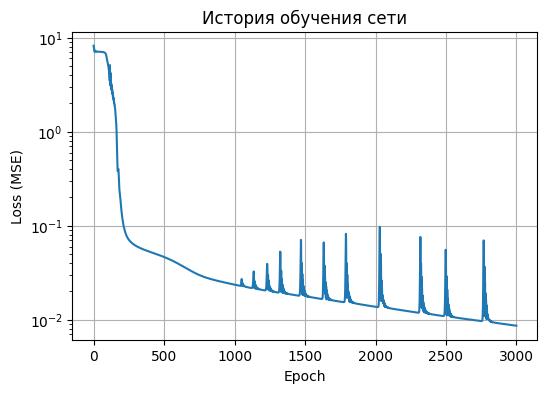

RuntimeError: [enforce fail at inline_container.cc:741] . open file failed with error code: 5

In [9]:
# Оптимизатор 1: Adam
if not is_trained:
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs_adam = 3000
    loss_history =[]

    print("=== Запуск оптимизатора Adam ===")
    for epoch in range(epochs_adam):
        optimizer_adam.zero_grad()
        loss, l_ic, l_bc, l_pde = calculate_loss(model)
        loss.backward()
        optimizer_adam.step()
        
        loss_history.append(loss.item())
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch:4d} | Total Loss: {loss.item():.4e} | IC: {l_ic.item():.4e} | BC: {l_bc.item():.4e} | PDE: {l_pde.item():.4e}")

    # Оптимизатор 2: L-BFGS (очень хорош для гладких физических задач)
    print("\n=== Запуск оптимизатора L-BFGS ===")
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(), 
        lr=1.0, 
        max_iter=2000, 
        tolerance_grad=1e-7, 
        tolerance_change=1e-9, 
        history_size=50
    )

    # Для L-BFGS нужна функция-замыкание (closure)
    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = calculate_loss(model)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    # Финальный лосс
    final_loss, f_ic, f_bc, f_pde = calculate_loss(model)
    print(f"Обучение завершено! Final Loss: {final_loss.item():.4e} (PDE: {f_pde.item():.4e})")

    # Построим график падения функции потерь (для Adam)
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history, label='Total Loss (Adam)')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('История обучения сети')
    plt.grid(True)
    plt.show()

    is_trained = True
else:
    print("Модель уже обучена, пропускаем обучение.")

In [17]:
# Сохранение весов модели
import os

model_file = r'C:\Users\nasty\local_projects\PZAD\model\weight\checkpoint.pth'
model_dir = os.path.dirname(model_file)

try:
    # Создаем папку если её нет
    os.makedirs(model_dir, exist_ok=True)
    
    # Сохраняем модель
    torch.save(model.state_dict(), model_file)
    print(f"✓ Веса модели успешно сохранены в '{model_file}'")
except Exception as e:
    print(f"✗ Ошибка при сохранении модели: {e}")
    print(f"✗ Проверьте права доступа к папке: {model_dir}")

✓ Веса модели успешно сохранены в 'C:\Users\nasty\local_projects\PZAD\model\weight\checkpoint.pth'


In [18]:
def solve_fdm(nx=50, ny=50, nt=500):
    """Классическое решение методом конечных разностей"""
    dx = L / (nx - 1); dy = L / (ny - 1); dt = T_max / nt
    u = np.full((ny, nx), T_ambient)
    
    # Итерационный цикл по времени
    for n in range(nt):
        un = u.copy()
        # Вычисляем источник для всей сетки
        x_m, y_m = np.meshgrid(np.linspace(0, L, nx), np.linspace(0, L, ny))
        # Аналог функции источника на numpy
        Q_fdm = 300.0 * np.exp(-((x_m - 0.5)**2 + (y_m - 0.5)**2) / (2 * 0.1**2))
        
        # Схема "явная по времени"
        u[1:-1, 1:-1] = (un[1:-1, 1:-1] +
                         alpha * dt / dx**2 * (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                         alpha * dt / dy**2 * (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1]) +
                         dt * Q_fdm[1:-1, 1:-1])
        # Граничные условия Дирихле (холодные края)
        u[0,:] = u[-1,:] = u[:,0] = u[:,-1] = T_ambient
        
    return u # Возвращает финальное состояние

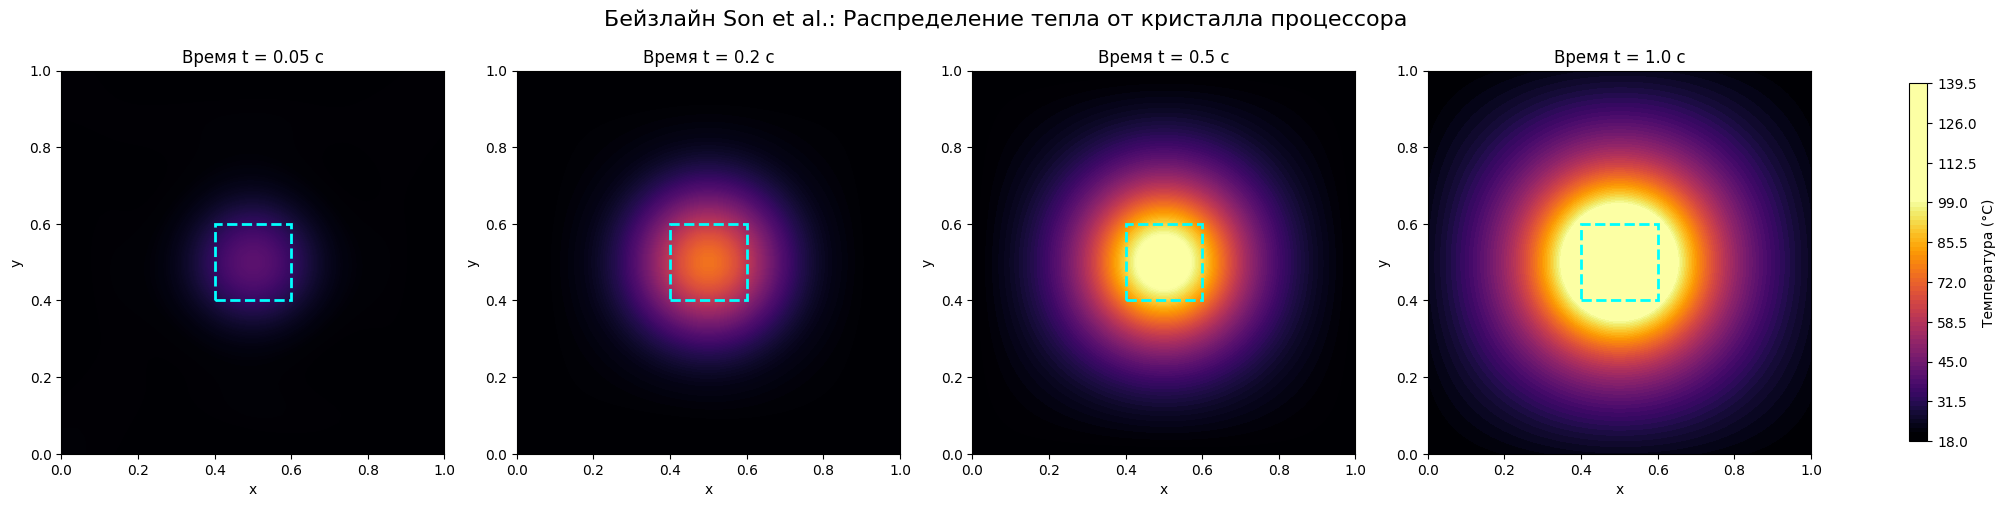

In [19]:

# Улучшенная визуализация для микропроцессорной модели
# Создаем сетку для визуализации
nx_vis, ny_vis = 50, 50
x_grid = np.linspace(0, L, nx_vis)
y_grid = np.linspace(0, L, ny_vis)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
X_flat = X_mesh.flatten()
Y_flat = Y_mesh.flatten()

time_steps = [0.05, 0.2, 0.5, 1.0] # Моменты времени
fig, axes = plt.subplots(1, len(time_steps), figsize=(20, 5), constrained_layout=True)

for ax, t_val in zip(axes, time_steps):
    T_flat = np.full_like(X_flat, t_val)
    X_t = torch.tensor(X_flat, dtype=torch.float32, device=device).reshape(-1, 1)
    Y_t = torch.tensor(Y_flat, dtype=torch.float32, device=device).reshape(-1, 1)
    T_t = torch.tensor(T_flat, dtype=torch.float32, device=device).reshape(-1, 1)

    # --- В ячейке визуализации (измени расчет U_pred) ---
    with torch.no_grad():
        # 1. Получаем предсказание нейросети
        U_norm = model(X_t, Y_t, T_t).cpu().numpy().reshape(ny_vis, nx_vis)
        
        # 2. Обратная трансформация (Де-нормализация)
        # Мы учили сеть, что границы (20) - это 0, а масштаб источника был ~100
        U_final = U_norm * 100.0 + 20.0 

    # Теперь рисуй тепловую карту для U_final
    cf = ax.contourf(X_mesh, Y_mesh, U_final, levels=100, cmap="inferno", vmin=20, vmax=100)
    
    # Рисуем контур "чипа" в центре для наглядности
    chip_rect = patches.Rectangle((0.4, 0.4), 0.2, 0.2, linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--', label='CPU Die')
    ax.add_patch(chip_rect)
    
    ax.set_title(f"Время t = {t_val} c")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

# Общий colorbar
cbar = fig.colorbar(cf, ax=axes, shrink=0.8)
cbar.set_label("Температура (°C)")
fig.suptitle("Бейзлайн Son et al.: Распределение тепла от кристалла процессора", fontsize=16)
plt.show()

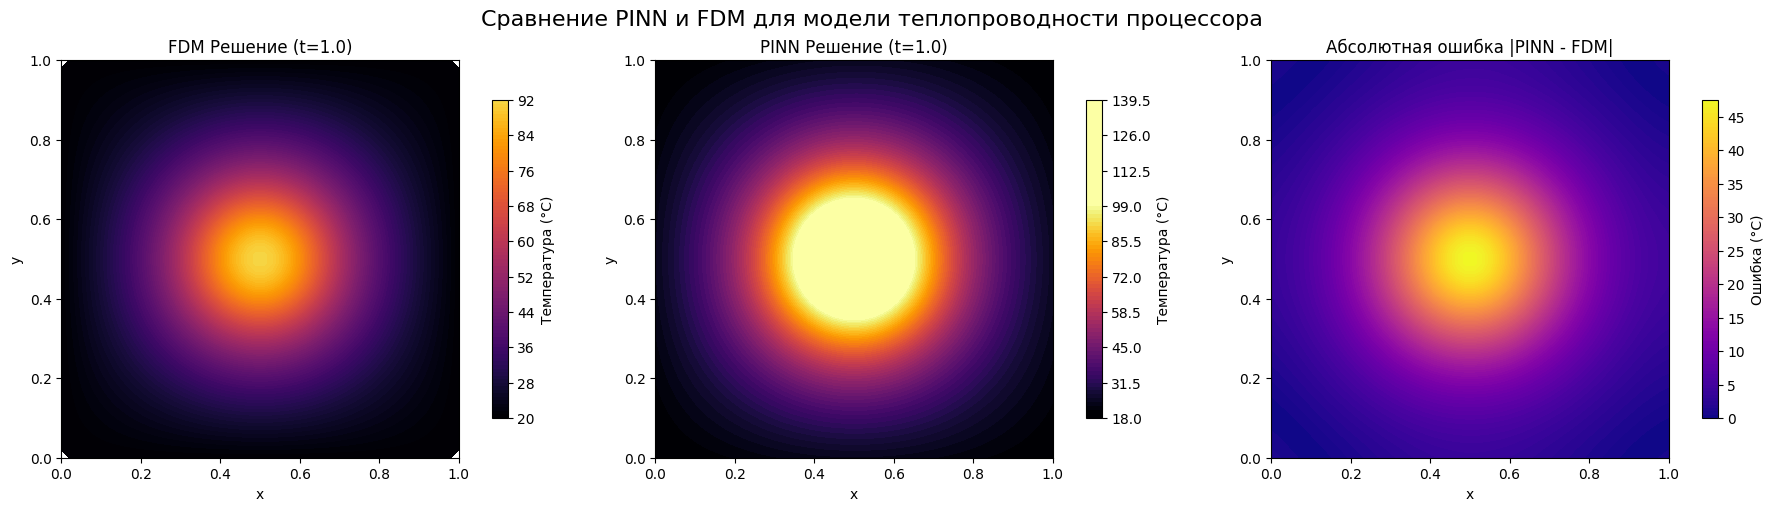

Метрики сравнения:
MSE: 222.8237 °C²
MAE: 10.5066 °C
Max Error: 47.1993 °C


In [20]:
# Сравнение PINN с методом конечных разностей (FDM)

# Создаем сетку для сравнения (та же, что и в FDM)
nx, ny = 50, 50
x_grid = np.linspace(0, L, nx)
y_grid = np.linspace(0, L, ny)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
X_flat = X_mesh.flatten()
Y_flat = Y_mesh.flatten()

# Получаем решение методом конечных разностей
u_fdm = solve_fdm(nx=nx, ny=ny, nt=500)

# Получаем предсказание PINN на финальном времени t = T_max
T_flat = np.full_like(X_flat, T_max)
X_t = torch.tensor(X_flat, dtype=torch.float32, device=device).reshape(-1, 1)
Y_t = torch.tensor(Y_flat, dtype=torch.float32, device=device).reshape(-1, 1)
T_t = torch.tensor(T_flat, dtype=torch.float32, device=device).reshape(-1, 1)

with torch.no_grad():
    U_pinn_norm = model(X_t, Y_t, T_t).cpu().numpy().reshape(ny, nx)
    # Обратная трансформация (как в визуализации)
    U_pinn = U_pinn_norm * 100.0 + 20.0

# Вычисляем абсолютную ошибку
error = np.abs(U_pinn - u_fdm)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# FDM решение
cf1 = axes[0].contourf(X_mesh, Y_mesh, u_fdm, levels=100, cmap="inferno", vmin=20, vmax=100)
axes[0].set_title("FDM Решение (t=1.0)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

# PINN решение
cf2 = axes[1].contourf(X_mesh, Y_mesh, U_pinn, levels=100, cmap="inferno", vmin=20, vmax=100)
axes[1].set_title("PINN Решение (t=1.0)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

# Абсолютная ошибка
cf3 = axes[2].contourf(X_mesh, Y_mesh, error, levels=100, cmap="plasma")
axes[2].set_title("Абсолютная ошибка |PINN - FDM|")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

# Общие colorbars
cbar1 = fig.colorbar(cf1, ax=axes[0], shrink=0.8)
cbar1.set_label("Температура (°C)")
cbar2 = fig.colorbar(cf2, ax=axes[1], shrink=0.8)
cbar2.set_label("Температура (°C)")
cbar3 = fig.colorbar(cf3, ax=axes[2], shrink=0.8)
cbar3.set_label("Ошибка (°C)")

fig.suptitle("Сравнение PINN и FDM для модели теплопроводности процессора", fontsize=16)
plt.show()

# Вычисляем метрики ошибки
mse_error = np.mean(error**2)
mae_error = np.mean(error)
max_error = np.max(error)

print(f"Метрики сравнения:")
print(f"MSE: {mse_error:.4f} °C²")
print(f"MAE: {mae_error:.4f} °C")
print(f"Max Error: {max_error:.4f} °C")